<a href="https://colab.research.google.com/github/ting3bi/cs9840/blob/main/CS9840Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### Large RAM is required to load the larger models. Running on GPU can optimize inference speed.

In [ ]:
# !rm -rf ~/.cache/huggingface

In [ ]:
from google.colab import drive
import os

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Create a dedicated directory in your Drive for AI models
# This ensures models persist and are not cleared by Colab
model_save_path = '/content/drive/MyDrive/AI_Models/huggingface_cache'
os.makedirs(model_save_path, exist_ok=True)

# 3. Set environment variable so all downloads are stored in this directory
os.environ['HUGGINGFACE_HUB_CACHE'] = model_save_path

print(f"Model cache directory: {model_save_path}")

Mounted at /content/drive
Model cache directory: /content/drive/MyDrive/AI_Models/huggingface_cache


In [ ]:
# Install latest versions of required packages
!pip install -U transformers accelerate bitsandbytes -q

import torch
from transformers import Blip2ForConditionalGeneration, Blip2Processor, BitsAndBytesConfig

device = torch.device("cuda") if torch.cuda.is_available() else "cpu"

# Configure 8-bit quantization (reduces GPU memory usage)
quantization_config = BitsAndBytesConfig(load_in_8bit=True)

# Load model
# First run will download to your Drive; subsequent runs will reuse the cached version
model = Blip2ForConditionalGeneration.from_pretrained(
    "Salesforce/blip2-opt-2.7b",
    quantization_config=quantization_config,
    device_map="auto"
)

# Load processor
processor = Blip2Processor.from_pretrained("Salesforce/blip2-opt-2.7b")

print("BLIP-2 model loaded and cached in Google Drive.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 89.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.8 MB/s eta 0:00:00


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

BLIP-2 model loaded and cached in Google Drive.


1. Using caption insteading using real VQA data




In [ ]:
# !mkdir -p /content/coco
# %cd /content/coco

# # download validation images (~6GB)
# !wget http://images.cocodataset.org/zips/val2014.zip
# !unzip -q val2014.zip

# # download annotations (~250MB)
# !mkdir annotations
# %cd annotations
# !wget http://images.cocodataset.org/annotations/annotations_trainval2014.zip
# !unzip -q annotations_trainval2014.zip

In [ ]:
# !rm /content/coco/val2014.zip
# !rm /content/coco/annotations/annotations_trainval2014.zip

# !mv /content/coco/annotations/annotations/* /content/coco/annotations/
# !rm -r /content/coco/annotations/annotations

In [ ]:
# from pycocotools.coco import COCO

# coco = COCO("/content/coco/annotations/captions_val2014.json")

# img_ids = coco.getImgIds()[:200]   #  #image = 200

# dataset = []

# for img_id in img_ids:
#     anns = coco.loadAnns(coco.getAnnIds(imgIds=img_id))

#     caption = anns[0]["caption"]  # get one caption

#     dataset.append({
#         "image_id": img_id,
#         "question": "what is in the image?",
#         "gt": caption
#     })

# print(len(dataset))

In [ ]:
import requests
from PIL import Image
from io import BytesIO

# def load_image(image_id):
#     path = f"/content/coco/val2014/COCO_val2014_{image_id:012d}.jpg"
#     return Image.open(path).convert("RGB")

In [ ]:
# # Extract noun
# import nltk
# nltk.download('averaged_perceptron_tagger')
# nltk.download('punkt')
# nltk.download('punkt_tab')
# nltk.download('averaged_perceptron_tagger_eng')

# from nltk import pos_tag, word_tokenize

# def extract_noun(caption):
#     words = word_tokenize(caption.lower())
#     tagged = pos_tag(words)

#     nouns = [word for word, tag in tagged if tag.startswith("NN")]

#     if len(nouns) > 0:
#         return nouns[-1]   # choose the last noun

#     return words[-1]

In [ ]:
# def build_vqa_samples(coco, img_ids, max_samples=200):
#     samples = []

#     for i, img_id in enumerate(img_ids):
#         ann_ids = coco.getAnnIds(imgIds=img_id)
#         anns = coco.loadAnns(ann_ids)

#         if len(anns) == 0:
#             continue

#         caption = anns[0]["caption"]

#         # very simple QA
#         question = "What is in the image?"
#         gt = extract_noun(caption)

#         # img_info = coco.loadImgs(img_id)[0]
#         # path = os.path.join(image_dir, img_info["file_name"])

#         # image = Image.open(path).convert("RGB")
#         image = load_image(img_id)

#         samples.append({
#             "image": image,
#             "question": question,
#             "gt": gt
#         })

#         if len(samples) >= max_samples:
#             break

#     return samples

In [ ]:
# samples = build_vqa_samples(
#     coco,
#     img_ids,
#     max_samples=200
# )

In [ ]:
!mkdir -p /content/drive/MyDrive/vqa_project/vqa
%cd /content/drive/MyDrive/vqa_project/vqa

!wget https://s3.amazonaws.com/cvmlp/vqa/mscoco/vqa/v2_Questions_Val_mscoco.zip
!wget https://s3.amazonaws.com/cvmlp/vqa/mscoco/vqa/v2_Annotations_Val_mscoco.zip

!unzip -q v2_Questions_Val_mscoco.zip
!unzip -q v2_Annotations_Val_mscoco.zip

/content/drive/MyDrive/vqa_project/vqa
--2026-04-04 17:31:39--  https://s3.amazonaws.com/cvmlp/vqa/mscoco/vqa/v2_Questions_Val_mscoco.zip
Resolving s3.amazonaws.com (s3.amazonaws.com)... 52.216.221.32, 52.216.222.56, 16.15.183.111, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|52.216.221.32|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3494929 (3.3M) [application/zip]
Saving to: ‘v2_Questions_Val_mscoco.zip.1’

v2_Questions_Val_ms 100%[===================>]   3.33M  5.31MB/s    in 0.6s    

2026-04-04 17:31:40 (5.31 MB/s) - ‘v2_Questions_Val_mscoco.zip.1’ saved [3494929/3494929]

--2026-04-04 17:31:40--  https://s3.amazonaws.com/cvmlp/vqa/mscoco/vqa/v2_Annotations_Val_mscoco.zip
Resolving s3.amazonaws.com (s3.amazonaws.com)... 52.216.221.32, 52.216.222.56, 16.15.183.111, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|52.216.221.32|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10518930 (10M) [application/zip]
Saving 

In [ ]:
!mkdir -p /content/drive/MyDrive/vqa_project/coco
%cd /content/drive/MyDrive/vqa_project/coco

!wget http://images.cocodataset.org/zips/val2014.zip
!unzip -q val2014.zipN


/content/drive/MyDrive/vqa_project/coco
--2026-04-04 17:36:23--  http://images.cocodataset.org/zips/val2014.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 52.216.216.57, 52.217.132.225, 52.216.62.57, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|52.216.216.57|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6645013297 (6.2G) [application/zip]
Saving to: ‘val2014.zip’

val2014.zip         100%[===================>]   6.19G  27.0MB/s    in 3m 29s  

2026-04-04 17:39:52 (30.4 MB/s) - ‘val2014.zip’ saved [6645013297/6645013297]

replace val2014/COCO_val2014_000000324670.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [ ]:
# remove zip file
!rm v2_Questions_Val_mscoco.zip
!rm v2_Annotations_Val_mscoco.zip
!rm val2014.zip

rm: cannot remove 'v2_Questions_Val_mscoco.zip': No such file or directory
rm: cannot remove 'v2_Annotations_Val_mscoco.zip': No such file or directory


In [ ]:
VQA_PATH = "/content/drive/MyDrive/vqa_project/vqa"
COCO_PATH = "/content/drive/MyDrive/vqa_project/coco/val2014"

In [ ]:
def load_image_vqa(image_id):
    path = f"{COCO_PATH}/COCO_val2014_{image_id:012d}.jpg"
    if not os.path.exists(path):
        return None
    return Image.open(path).convert("RGB")

In [ ]:
import json, random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Load VQA files
with open("/content/drive/MyDrive/vqa_project/vqa/v2_OpenEnded_mscoco_val2014_questions.json") as f:
    questions = json.load(f)["questions"]

with open("/content/drive/MyDrive/vqa_project/vqa/v2_mscoco_val2014_annotations.json") as f:
    annotations = json.load(f)["annotations"]

# Map annotations
ann_by_qid = {a["question_id"]: a for a in annotations}

# Bucket by answer type
from collections import defaultdict
buckets = defaultdict(list)

for q in questions:
    qid = q["question_id"]
    ann = ann_by_qid.get(qid)
    if ann is None:
        continue

    buckets[ann["answer_type"]].append({
        "question_id": qid,
        "image_id": q["image_id"],
        "question": q["question"],
        "answers": [x["answer"] for x in ann["answers"]],
        "answer_type": ann["answer_type"]
    })

# Sample subset (COLAB SAFE SIZE)
target = {"yes/no": 100, "number": 100, "other": 300}

samples = []
for k, n in target.items():
    items = buckets[k]
    random.shuffle(items)
    samples.extend(items[:n])

random.shuffle(samples)

print("Total samples:", len(samples))

Total samples: 500


In [ ]:
import torch
import numpy as np

def compute_candidate_confidence(model, processor, image, question, candidates, device):
    log_probs = []

    for cand in candidates:
        prompt = f"Question: {question} Answer: {cand}"

        inputs = processor(
            images=image,
            text=prompt,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)

        logits = outputs.logits  # [1, T, vocab]
        input_ids = inputs["input_ids"]

        # shift for next-token prediction
        shift_logits = logits[:, :-1, :]
        shift_labels = input_ids[:, 1:]

        log_probs_tokens = torch.log_softmax(shift_logits, dim=-1)

        token_log_probs = torch.gather(
            log_probs_tokens,
            2,
            shift_labels.unsqueeze(-1)
        ).squeeze(-1)

        # sum log prob of sequence
        seq_log_prob = token_log_probs.sum().item()
        log_probs.append(seq_log_prob)

    # convert to probabilities
    log_probs = np.array(log_probs)

    # stabilize softmax
    log_probs = log_probs - np.max(log_probs)

    probs = np.exp(log_probs)
    probs = probs / probs.sum()

    confidence = float(np.max(probs))
    best_idx = int(np.argmax(probs))

    return confidence, candidates[best_idx], probs, log_probs


# def compute_confidence(outputs, inputs, processor, model):
#     sequences = outputs.sequences
#     scores = outputs.scores

#     if len(scores) == 0:
#         return 0.0

#     stacked_scores = torch.stack(scores, dim=1)
#     log_probs = torch.log_softmax(stacked_scores, dim=-1)

#     prompt_len = inputs["input_ids"].shape[1]
#     T = len(scores)

#     generated_ids = sequences[:, prompt_len:prompt_len + T]

#     chosen_log_probs = torch.gather(
#         log_probs,
#         dim=2,
#         index=generated_ids.unsqueeze(-1)
#     ).squeeze(-1)

#     # filter EOS / PAD
#     pad_token_id = processor.tokenizer.pad_token_id
#     eos_token_id = model.config.text_config.eos_token_id

#     valid_log_probs = []

#     for tid, lp in zip(generated_ids[0], chosen_log_probs[0]):
#         tid = tid.item()

#         if pad_token_id is not None and tid == pad_token_id:
#             break
#         if eos_token_id is not None and tid == eos_token_id:
#             break

#         valid_log_probs.append(lp.item())

#     if len(valid_log_probs) == 0:
#         return 0.0

#     mean_logprob = sum(valid_log_probs) / len(valid_log_probs)
#     mean_prob = float(np.exp(mean_logprob))

#     return mean_prob

Following process for caption only

In [ ]:
import pandas as pd
#import numpy as np
import re
import os

results = []

# Normalize function
def normalize(s):
    s = s.lower()
    s = re.sub(r"[^\w\s]", "", s)   # remove all punctuation
    s = s.strip()
    return s

# def vqa_score(pred, answers):
#     pred = normalize(pred)
#     matches = sum([1 for a in answers if normalize(a) == pred])
#     return min(matches / 3.0, 1.0)

for i, sample in enumerate(samples):

    image = load_image_vqa(sample["image_id"])
    if image is None:
        continue

    question = f"Question: {sample['question']} Answer:"

    # FIXED: get GT
    answers = sample["answers"]
    gt = max(set(answers), key=answers.count)

    inputs = processor(
        images=image,
        text=question,
        return_tensors="pt"
    ).to(device, torch.float16)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            return_dict_in_generate=True,
            output_scores=True,
            max_new_tokens=20,
            do_sample=False
        )

    generated_ids = outputs.sequences
    input_len = inputs["input_ids"].shape[1]
    new_ids = generated_ids[:, input_len:]

    answer = processor.batch_decode(
        new_ids,
        skip_special_tokens=True
    )[0].strip()

    # confidence = compute_confidence(outputs, inputs, processor, model)


    #candidates = list(set(sample["answers"]))[:5] # unique answers choose the first 5 candiates
    answers = sample["answers"]
    candidates = list(dict.fromkeys(answers))   # unique, preserve order
    gt = max(set(answers), key=answers.count)

    confidence, pred_answer, probs, logits = compute_candidate_confidence(
      model,
      processor,
      image,
      sample["question"],
      candidates,
      device
    )

    threshold = 0.6
    abstained = int(confidence < threshold)

    if abstained:
      pred_answer = "I don't know"

    pred_answer = normalize(pred_answer)
    gt = normalize(gt)

    answer = pred_answer


    # score = vqa_score(answer, sample["answers"])
    # correct = int(score > 0.5)

    correct = int(normalize(pred_answer) == normalize(gt)) if not abstained else 0;

    results.append({
      "question": sample["question"],
      "predicted_answer": pred_answer,
      "ground_truth": gt,
      "confidence": confidence,
      "correct": correct,
      "candidates": candidates,
      "probs": probs.tolist(),
      "logits": logits.tolist()
    })

    print(f"{i}")
    print(f"Q: {sample['question']}")
    print(f"GT: {gt}")
    print(f"Pred: {answer}")
    print(f"Correct: {correct}, Confidence: {confidence:.3f}")
    print("-" * 50)

    if len(results) % 10 == 0:
        df_tmp = pd.DataFrame(results)
        df_tmp.to_parquet("/content/drive/MyDrive/vlm_results.parquet")
        print(f"Auto-saved at {len(results)} samples")

# 10. Final DataFrame
df = pd.DataFrame(results)

/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


0
Q: Is this in America?
GT: no
Pred: no
Correct: 1, Confidence: 1.000
--------------------------------------------------
1
Q: What is in the back of the truck?
GT: elephant
Pred: elephant
Correct: 1, Confidence: 1.000
--------------------------------------------------
2
Q: What number is the batter?
GT: 24
Pred: 24
Correct: 1, Confidence: 1.000
--------------------------------------------------
3
Q: What sport is the man playing?
GT: tennis
Pred: tennis
Correct: 1, Confidence: 1.000
--------------------------------------------------
4
Q: If the people at the intersection where to cross, would they be jaywalking?
GT: no
Pred: no
Correct: 1, Confidence: 0.969
--------------------------------------------------
5
Q: Why is she holding a carrot?
GT: she grew it
Pred: yes
Correct: 0, Confidence: 0.788
--------------------------------------------------
6
Q: What is the food in the person's' hand?
GT: sandwich
Pred: bread
Correct: 0, Confidence: 0.630
-----------------------------------------

In [ ]:
def compute_ece(confidences, correct, n_bins=10):
    confidences = np.asarray(confidences)
    correct = np.asarray(correct)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        lower = bin_edges[i]
        upper = bin_edges[i + 1]

        if i == 0:
            in_bin = (confidences >= lower) & (confidences <= upper)
        else:
            in_bin = (confidences > lower) & (confidences <= upper)

        if np.any(in_bin):
            bin_acc = np.mean(correct[in_bin])
            bin_conf = np.mean(confidences[in_bin])
            ece += np.abs(bin_acc - bin_conf) * np.mean(in_bin)

    return float(ece)

In [ ]:
ece = compute_ece(df["confidence"], df["correct"])
print("ECE:", ece)

ECE: 0.32095913388469355


In [ ]:
def compute_nll_from_candidates(df, eps=1e-12):
    losses = []

    for _, row in df.iterrows():
        gt = normalize(row["ground_truth"])
        candidates = row["candidates"]
        probs = row["probs"]

        prob_true = 0.0

        for cand, p in zip(candidates, probs):
            if normalize(cand) == gt:
                prob_true = float(p)
                break

        prob_true = max(prob_true, eps)
        losses.append(-np.log(prob_true))

    return float(np.mean(losses))

In [ ]:
nll = compute_nll_from_candidates(df)
print("NLL:", nll)

NLL: 1.8652728284891105


In [ ]:
accuracy = df["correct"].mean()
print("Accuracy:", accuracy)

Accuracy: 0.558


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams["svg.fonttype"] = "none"

def plot_reliability(confidences, correct, n_bins=10, title="Reliability Diagram", save_path=None):
    confidences = np.array(confidences)
    correct = np.array(correct)

    bins = np.linspace(0, 1, n_bins + 1)

    bin_acc = []
    bin_conf = []

    for i in range(n_bins):
        lower = bins[i]
        upper = bins[i + 1]

        in_bin = (confidences > lower) & (confidences <= upper)

        if np.sum(in_bin) > 0:
            acc = np.mean(correct[in_bin])
            conf = np.mean(confidences[in_bin])
        else:
            acc = 0
            conf = (lower + upper) / 2

        bin_acc.append(acc)
        bin_conf.append(conf)

    plt.figure(figsize=(5, 4))
    plt.plot(bin_conf, bin_acc, marker='o', label="Model")
    plt.plot([0, 1], [0, 1], linestyle='--', label="Perfect Calibration")

    plt.xlabel("Confidence")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.legend()
    plt.grid(True)

    if save_path is not None:
        plt.savefig(save_path, format="svg", bbox_inches="tight")

    plt.show()
    plt.close()

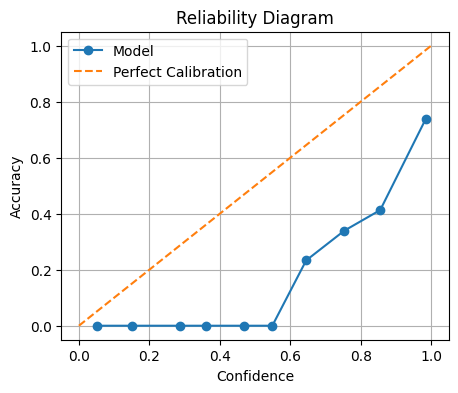

In [ ]:
plot_reliability(df["confidence"], df["correct"])

Using Temperature Scaling

In [ ]:
def softmax_with_temp(logits, T):
    logits = np.array(logits) / T
    logits = logits - np.max(logits)
    probs = np.exp(logits)
    return probs / probs.sum()

In [ ]:
val_df = df.sample(frac=0.2, random_state=42)
test_df = df.drop(val_df.index)

In [ ]:
def find_best_temperature(df):
    Ts = np.linspace(0.1, 5.0, 50)

    best_T = 1.0
    best_nll = float("inf")

    for T in Ts:
        total_nll = 0.0

        for _, row in df.iterrows():
            logits = row["logits"]

            probs_T = softmax_with_temp(logits, T)

            gt = normalize(row["ground_truth"])

            prob_true = 0.0
            for cand, p in zip(row["candidates"], probs_T):
                if normalize(cand) == gt:
                    prob_true = p
                    break

            prob_true = max(prob_true, 1e-12)
            total_nll += -np.log(prob_true)

        avg_nll = total_nll / len(df)

        if avg_nll < best_nll:
            best_nll = avg_nll
            best_T = T

    return best_T

In [ ]:
T_opt = find_best_temperature(val_df)

In [ ]:
def compute_confidence_with_T(row, T):
    probs_T = softmax_with_temp(row["logits"], T)
    return np.max(probs_T)

test_df["confidence_T"] = test_df.apply(
    lambda row: compute_confidence_with_T(row, T_opt),
    axis=1
)

In [ ]:
ece_before = compute_ece(test_df["confidence"], test_df["correct"])
ece_after  = compute_ece(test_df["confidence_T"], test_df["correct"])

print("ECE before:", ece_before)
print("ECE after:", ece_after)

ECE before: 0.3265168507152386
ECE after: 0.09724821165305023


In [ ]:
def compute_nll_with_temperature(df, T, eps=1e-12):
    losses = []

    for _, row in df.iterrows():
        logits = row["logits"]
        candidates = row["candidates"]
        gt = normalize(row["ground_truth"])

        # apply temperature
        probs_T = softmax_with_temp(logits, T)

        # find probability of ground truth
        prob_true = 0.0
        for cand, p in zip(candidates, probs_T):
            if normalize(cand) == gt:
                prob_true = float(p)
                break

        prob_true = max(prob_true, eps)
        losses.append(-np.log(prob_true))

    return float(np.mean(losses))

MC dropout

In [ ]:
def enable_dropout(model):
    for m in model.modules():
        if m.__class__.__name__.startswith('Dropout'):
            m.train()

In [ ]:
def mc_dropout_predict(model, processor, image, question, candidates, device, n_samples=5):
    probs_list = []

    enable_dropout(model)

    for _ in range(n_samples):
        _, _, probs, logits = compute_candidate_confidence(
            model, processor, image, question, candidates, device
        )
        probs_list.append(probs)

    probs_mean = np.mean(probs_list, axis=0)

    confidence = np.max(probs_mean)
    pred = candidates[np.argmax(probs_mean)]

    return confidence, pred, probs_mean

In [ ]:
mc_results = []

def vqa_score(pred, answers):
    pred = normalize(pred)
    matches = sum([1 for a in answers if normalize(a) == pred])
    return min(matches / 3.0, 1.0)

for i, sample in enumerate(samples):  # run with small samples
    image = load_image_vqa(sample["image_id"])
    if image is None:
        continue

    question = sample["question"]
    answers = sample["answers"]

    gt = max(set(answers), key=answers.count)
    candidates = list(dict.fromkeys(answers))

    confidence_mc, pred_mc, probs_mc = mc_dropout_predict(
        model, processor, image, question, candidates, device, n_samples=5
    )

    pred_mc = normalize(pred_mc)
    gt = normalize(gt)
    # correct_mc = int(pred_mc == gt)

    score = vqa_score(pred_mc, sample["answers"])
    correct_mc = float(score)

    mc_results.append({
        "question": question,
        "ground_truth": gt,
        "predicted_answer": pred_mc,
        "confidence": float(confidence_mc),
        "correct": correct_mc,
        "candidates": candidates,
        "probs": probs_mc.tolist()
    })

mc_df = pd.DataFrame(mc_results)

/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


Laplace approximation

In [ ]:
def laplace_approx_predict(logits, candidates, sigma=0.1, n_samples=10):
    probs_list = []

    for _ in range(n_samples):
        noisy_logits = logits + np.random.normal(0, sigma, size=len(logits))
        probs = np.exp(noisy_logits - np.max(noisy_logits))
        probs /= probs.sum()
        probs_list.append(probs)

    probs_mean = np.mean(probs_list, axis=0)

    confidence = np.max(probs_mean)
    pred = candidates[np.argmax(probs_mean)]

    return confidence, pred, probs_mean

In [ ]:
laplace_results = []

for _, row in df.iterrows():
    candidates = row["candidates"]
    gt = normalize(row["ground_truth"])
    logits = np.array(row["logits"])

    confidence_lap, pred_lap, probs_lap = laplace_approx_predict(
        logits, candidates, sigma=0.1, n_samples=10
    )

    pred_lap = normalize(pred_lap)
    correct_lap = int(pred_lap == gt)

    laplace_results.append({
        "question": row["question"],
        "ground_truth": gt,
        "predicted_answer": pred_lap,
        "confidence": float(confidence_lap),
        "correct": correct_lap,
        "candidates": candidates,
        "probs": probs_lap.tolist()
    })

laplace_df = pd.DataFrame(laplace_results)

Result

In [ ]:
# acc
baseline_acc = df["correct"].mean()
mc_acc = mc_df["correct"].mean()
laplace_acc = laplace_df["correct"].mean()

print("Baseline Accuracy:", baseline_acc)
print("MC Dropout Accuracy:", mc_acc)
print("Laplace Accuracy:", laplace_acc)

Baseline Accuracy: 0.558
MC Dropout Accuracy: 0.8146666666666668
Laplace Accuracy: 0.578


In [ ]:
# ECE
baseline_ece = compute_ece(df["confidence"], df["correct"])
mc_ece = compute_ece(mc_df["confidence"], mc_df["correct"])
laplace_ece = compute_ece(laplace_df["confidence"], laplace_df["correct"])

print("Baseline ECE:", baseline_ece)
print("MC Dropout ECE:", mc_ece)
print("Laplace ECE:", laplace_ece)

Baseline ECE: 0.32095913388469355
MC Dropout ECE: 0.11196994601203109
Laplace ECE: 0.3008058906948473


In [ ]:
# NLL
baseline_nll = compute_nll_from_candidates(df)
mc_nll = compute_nll_from_candidates(mc_df)
laplace_nll = compute_nll_from_candidates(laplace_df)

print("Baseline NLL:", baseline_nll)
print("MC Dropout NLL:", mc_nll)
print("Laplace NLL:", laplace_nll)

Baseline NLL: 1.8652728284891105
MC Dropout NLL: 1.013059268189548
Laplace NLL: 1.863784132253902


In [ ]:
# summary across baseline, Tempareture scaling, MC dropout, lightweight Laplace Approximation
comparison = pd.DataFrame([
    {
        "Method": "Baseline",
        "Accuracy": df["correct"].mean(),
        "ECE": compute_ece(df["confidence"], df["correct"]),
        "NLL": compute_nll_from_candidates(df),
    },
    {
        "Method": "Temperature Scaling",
        "Accuracy": test_df["correct"].mean(),
        "ECE": compute_ece(test_df["confidence_T"], test_df["correct"]),
        "NLL": compute_nll_with_temperature(test_df, T_opt),
    },
    {
        "Method": "MC Dropout",
        "Accuracy": mc_df["correct"].mean(),
        "ECE": compute_ece(mc_df["confidence"], mc_df["correct"]),
        "NLL": compute_nll_from_candidates(mc_df),
    },
    {
        "Method": "Laplace Approx",
        "Accuracy": laplace_df["correct"].mean(),
        "ECE": compute_ece(laplace_df["confidence"], laplace_df["correct"]),
        "NLL": compute_nll_from_candidates(laplace_df),
    },
])

print(comparison)

                Method  Accuracy       ECE       NLL
0             Baseline  0.558000  0.320959  1.865273
1  Temperature Scaling  0.550000  0.097248  0.884396
2           MC Dropout  0.814667  0.111970  1.013059
3       Laplace Approx  0.578000  0.300806  1.863784


Baseline


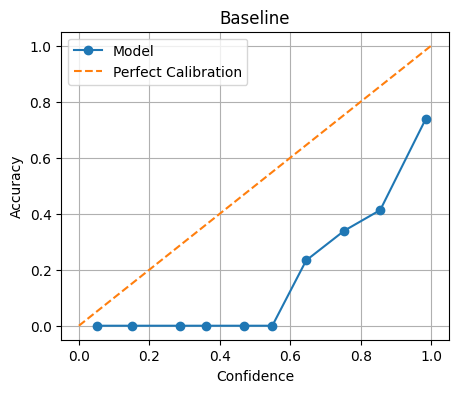

Temperature Scaling - After


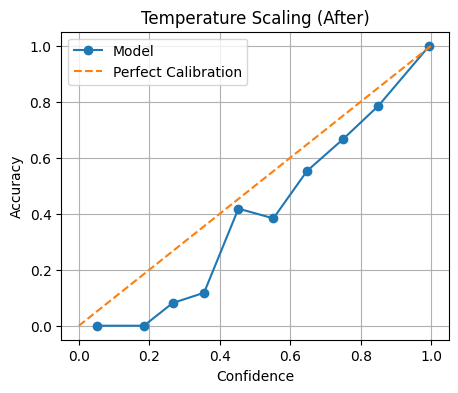

MC Dropout


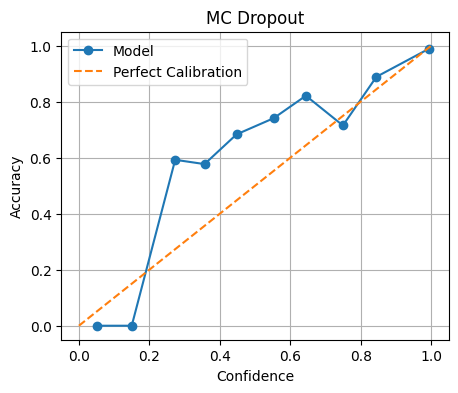

Laplace Approx


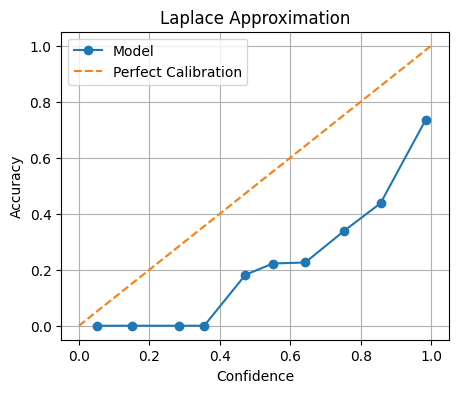

In [ ]:
print("Baseline")
plot_reliability(
    df["confidence"],
    df["correct"],
    n_bins=10,
    title="Baseline",
    save_path="baseline_reliability.svg"
)


print("Temperature Scaling - After")
plot_reliability(
    test_df["confidence_T"],
    test_df["correct"],
    n_bins=10,
    title="Temperature Scaling (After)",
    save_path="temp_after_reliability.svg"
)

print("MC Dropout")
plot_reliability(
    mc_df["confidence"],
    mc_df["correct"],
    n_bins=10,
    title="MC Dropout",
    save_path="mc_dropout_reliability.svg"
)

print("Laplace Approx")
plot_reliability(
    laplace_df["confidence"],
    laplace_df["correct"],
    n_bins=10,
    title="Laplace Approximation",
    save_path="laplace_reliability.svg"
)

In [ ]:
print(os.getcwd())

/content/drive/MyDrive/vqa_project/coco


#### Load an example image